In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr

20220714
['TIME_START' 'P_MMS' 'T_MMS' 'G_LAT_MMS' 'G_LONG_MMS' 'G_ALT_MMS'
 'POT_MMS']
20220714
['TIME_MID' 'H2O_ChiWIS']
<xarray.Dataset>
Dimensions:          (date: 1, time_from_start: 13999)
Coordinates:
  * date             (date) <U8 '20220714'
  * time_from_start  (time_from_start) float64 0.0 1.0 2.0 ... 1.4e+04 1.4e+04
Data variables:
    lat              (date, time_from_start) float64 2.959e+06 ... 2.961e+06
    lon              (date, time_from_start) float64 -9.516e+06 ... -9.516e+06
    alt              (date, time_from_start) float64 3.379e+03 ... 325.0
    pres             (date, time_from_start) float64 9.808e+04 ... 1.015e+05
    temp             (date, time_from_start) float64 2.986e+04 ... 3.058e+04
    theta            (date, time_from_start) float64 3.003e+04 ... 3.044e+04
    h2o_ChiWIS       (date, time_from_start) float64 nan nan nan ... nan nan nan


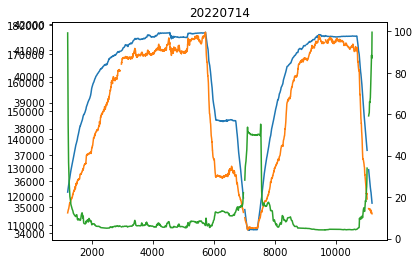

20220714
duration =  2.7683333333333313
altitude range =  10.8234 17.758
theta range =  341.12 417.0
2.77 & 10.8 - 17.8 & 341.1 - 417.0



In [12]:
path = "ACCLIP_Clare/"
wf = path+"ACCLIP-ChiWIS-ALL_WB57_20220714_RA.ict"
mf = path+"ACCLIP-MMS-1HZ_WB57_20220714_R0.ict"

f = mf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=53, max_rows=1, delimiter=",", dtype=str, usecols=[0,1,2,9,10,11,12]))
print(col_header)
ll = np.loadtxt(f, skiprows=54, delimiter=",", usecols=[0,1,2,9,10,11,12])
time = ll[:,0]
ds_w = xr.Dataset(
    data_vars=dict(
        lat=(["date","time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LAT_MMS')[0][0]], axis=0)),
        lon=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LONG_MMS')[0][0]], axis=0)),
        alt=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_ALT_MMS')[0][0]], axis=0)),
        pres=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'P_MMS')[0][0]], axis=0)),
        temp=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'T_MMS')[0][0]], axis=0)),
        theta=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'POT_MMS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_w = ds_w.where(ds_w.alt > 0)


f = wf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=44, max_rows=1, delimiter=",", dtype=str, usecols=[2,3]))
print(col_header)
ll = np.loadtxt(f, skiprows=45, delimiter=",", usecols=[2,3])
time = ll[:,0]
ds_f = xr.Dataset(
    data_vars=dict(
        h2o_ChiWIS=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_ChiWIS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_f = ds_f.where(ds_f.h2o_ChiWIS > 0)
ds_f_interp = ds_f.interp(time=ds_w.time, method="linear")

dsX = xr.merge([ds_w, ds_f_interp])
dsX["time_from_start"] = dsX.time - dsX.time[0]
dsX = dsX.swap_dims({"time":"time_from_start"})
dsX = dsX.drop_vars(["time"])
print(dsX)

ds_sub100 = dsX.where((dsX.h2o_ChiWIS <= 100.0) & (dsX.h2o_ChiWIS >= 0.1) & (dsX.alt >= 1) )
ds_sub100

for d in ds_sub100.date:
    di = ds_sub100.sel(date=d)
    
    plt.plot(di.time_from_start, di.alt)
    plt.twinx()
    plt.plot(di.time_from_start, di.theta, color="C1")
    plt.twinx()
    plt.plot(di.time_from_start, di.h2o_ChiWIS, color="C2")
    plt.title(d.values)
    plt.show()
    
    print(d.values)
    duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
    print("duration = ", duration.values / 3600.)
    print("altitude range = ", di.alt.min().values / 1e4, di.alt.max().values / 1e4)
    print("theta range = ", di.theta.min().values / 1e2, di.theta.max().values / 1e2)
    print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e4:.1f} - {di.alt.max().values / 1e4:.1f} & {di.theta.min().values / 1e2:.1f} - {di.theta.max().values / 1e2:.1f}")
    print()

20210806
['TIME_START' 'P_MMS' 'T_MMS' 'G_LAT_MMS' 'G_LONG_MMS' 'G_ALT_MMS'
 'POT_MMS']
20210806
['TIME_MID' 'H2O_ChiWIS']


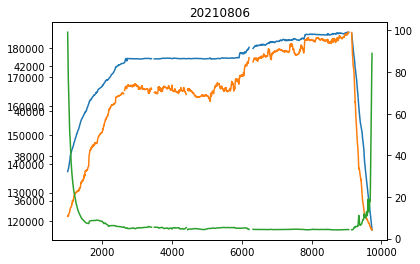

20210806
duration =  2.422779166666666
altitude range =  11.7074 18.5511
theta range =  346.97 434.96
2.42 & 11.7 - 18.6 & 347.0 - 435.0



In [20]:
path = "ACCLIP_Clare/"
wf = path+"ACCLIP-ChiWIS-ALL_WB57_20210806_R0.ict"
mf = path+"ACCLIP-MMS-1HZ_WB57_20210806_RA.ict"

f = mf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=52, max_rows=1, delimiter=",", dtype=str, usecols=[0,1,2,9,10,11,12]))
print(col_header)
ll = np.loadtxt(f, skiprows=53, delimiter=",", usecols=[0,1,2,9,10,11,12])
time = ll[:,0]
ds_w = xr.Dataset(
    data_vars=dict(
        lat=(["date","time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LAT_MMS')[0][0]], axis=0)),
        lon=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LONG_MMS')[0][0]], axis=0)),
        alt=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_ALT_MMS')[0][0]], axis=0)),
        pres=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'P_MMS')[0][0]], axis=0)),
        temp=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'T_MMS')[0][0]], axis=0)),
        theta=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'POT_MMS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_w = ds_w.where(ds_w.alt > 0)

f = wf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=44, max_rows=1, delimiter=",", dtype=str, usecols=[2,3]))
print(col_header)
ll = np.loadtxt(f, skiprows=45, delimiter=",", usecols=[2,3])
time = ll[:,0]
ds_f = xr.Dataset(
    data_vars=dict(
        h2o_ChiWIS=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_ChiWIS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_f = ds_f.where(ds_f.h2o_ChiWIS > 0)
ds_f_interp = ds_f.interp(time=ds_w.time, method="linear")

dsX = xr.merge([ds_w, ds_f_interp])
dsX["time_from_start"] = dsX.time - dsX.time[0]
dsX = dsX.swap_dims({"time":"time_from_start"})
dsX = dsX.drop_vars(["time"])
dsX

ds_sub100 = dsX.where((dsX.h2o_ChiWIS <= 100.0) & (dsX.h2o_ChiWIS >= 0.1) & (dsX.alt >= 1) )
ds_sub100

for d in ds_sub100.date:
    di = ds_sub100.sel(date=d)
    
    plt.plot(di.time_from_start, di.alt)
    plt.twinx()
    plt.plot(di.time_from_start, di.theta, color="C1")
    plt.twinx()
    plt.plot(di.time_from_start, di.h2o_ChiWIS, color="C2")
    plt.title(d.values)
    plt.show()
    
    print(d.values)
    duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
    print("duration = ", duration.values / 3600.)
    print("altitude range = ", di.alt.min().values / 1e4, di.alt.max().values / 1e4)
    print("theta range = ", di.theta.min().values / 1e2, di.theta.max().values / 1e2)
    print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e4:.1f} - {di.alt.max().values / 1e4:.1f} & {di.theta.min().values / 1e2:.1f} - {di.theta.max().values / 1e2:.1f}")
    print()

20210810
['TIME_START' 'P_MMS' 'T_MMS' 'G_LAT_MMS' 'G_LONG_MMS' 'G_ALT_MMS'
 'POT_MMS']
20210810
['TIME_MID' 'H2O_ChiWIS']


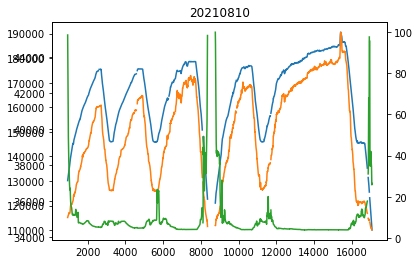

20210810
duration =  4.479721111111109
altitude range =  11.0116 19.0544
theta range =  343.95 453.56
4.48 & 11.0 - 19.1 & 343.9 - 453.6



In [21]:
path = "ACCLIP_Clare/"
wf = path+"ACCLIP-ChiWIS-ALL_WB57_20210810_RA.ict"
mf = path+"ACCLIP-MMS-1HZ_WB57_20210810_RA.ict"

f = mf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=52, max_rows=1, delimiter=",", dtype=str, usecols=[0,1,2,9,10,11,12]))
print(col_header)
ll = np.loadtxt(f, skiprows=53, delimiter=",", usecols=[0,1,2,9,10,11,12])
time = ll[:,0]
ds_w = xr.Dataset(
    data_vars=dict(
        lat=(["date","time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LAT_MMS')[0][0]], axis=0)),
        lon=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LONG_MMS')[0][0]], axis=0)),
        alt=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_ALT_MMS')[0][0]], axis=0)),
        pres=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'P_MMS')[0][0]], axis=0)),
        temp=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'T_MMS')[0][0]], axis=0)),
        theta=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'POT_MMS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_w = ds_w.where(ds_w.alt > 0)

f = wf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=44, max_rows=1, delimiter=",", dtype=str, usecols=[2,3]))
print(col_header)
ll = np.loadtxt(f, skiprows=45, delimiter=",", usecols=[2,3])
time = ll[:,0]
ds_f = xr.Dataset(
    data_vars=dict(
        h2o_ChiWIS=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_ChiWIS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_f = ds_f.where(ds_f.h2o_ChiWIS > 0)
ds_f_interp = ds_f.interp(time=ds_w.time, method="linear")

dsX = xr.merge([ds_w, ds_f_interp])
dsX["time_from_start"] = dsX.time - dsX.time[0]
dsX = dsX.swap_dims({"time":"time_from_start"})
dsX = dsX.drop_vars(["time"])
dsX

ds_sub100 = dsX.where((dsX.h2o_ChiWIS <= 100.0) & (dsX.h2o_ChiWIS >= 0.1) & (dsX.alt >= 1) )
ds_sub100

for d in ds_sub100.date:
    di = ds_sub100.sel(date=d)
    
    plt.plot(di.time_from_start, di.alt)
    plt.twinx()
    plt.plot(di.time_from_start, di.theta, color="C1")
    plt.twinx()
    plt.plot(di.time_from_start, di.h2o_ChiWIS, color="C2")
    plt.title(d.values)
    plt.show()
    
    print(d.values)
    duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
    print("duration = ", duration.values / 3600.)
    print("altitude range = ", di.alt.min().values / 1e4, di.alt.max().values / 1e4)
    print("theta range = ", di.theta.min().values / 1e2, di.theta.max().values / 1e2)
    print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e4:.1f} - {di.alt.max().values / 1e4:.1f} & {di.theta.min().values / 1e2:.1f} - {di.theta.max().values / 1e2:.1f}")
    print()

20210817
['TIME_START' 'P_MMS' 'T_MMS' 'G_LAT_MMS' 'G_LONG_MMS' 'G_ALT_MMS'
 'POT_MMS']
20210817
['TIME_MID' 'H2O_ChiWIS']


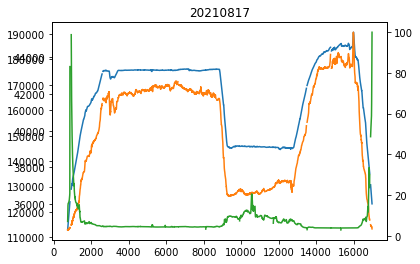

20210817
duration =  4.506110277777779
altitude range =  11.293 19.0701
theta range =  346.09 453.47
4.51 & 11.3 - 19.1 & 346.1 - 453.5



In [22]:
path = "ACCLIP_Clare/"
wf = path+"ACCLIP-ChiWIS-ALL_WB57_20210817_RA.ict"
mf = path+"ACCLIP-MMS-1HZ_WB57_20210817_RA.ict"

f = mf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=52, max_rows=1, delimiter=",", dtype=str, usecols=[0,1,2,9,10,11,12]))
print(col_header)
ll = np.loadtxt(f, skiprows=53, delimiter=",", usecols=[0,1,2,9,10,11,12])
time = ll[:,0]
ds_w = xr.Dataset(
    data_vars=dict(
        lat=(["date","time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LAT_MMS')[0][0]], axis=0)),
        lon=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_LONG_MMS')[0][0]], axis=0)),
        alt=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'G_ALT_MMS')[0][0]], axis=0)),
        pres=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'P_MMS')[0][0]], axis=0)),
        temp=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'T_MMS')[0][0]], axis=0)),
        theta=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'POT_MMS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_w = ds_w.where(ds_w.alt > 0)

f = wf
date = f.split("_")[-2]
print(date)
col_header = np.char.strip(np.loadtxt(f, skiprows=44, max_rows=1, delimiter=",", dtype=str, usecols=[2,3]))
print(col_header)
ll = np.loadtxt(f, skiprows=45, delimiter=",", usecols=[2,3])
time = ll[:,0]
ds_f = xr.Dataset(
    data_vars=dict(
        h2o_ChiWIS=(["date", "time"], np.expand_dims(ll[:,np.argwhere(col_header == 'H2O_ChiWIS')[0][0]], axis=0)),
    ),
    coords=dict(
        time=("time", time),
        date=[date],
    ),
)
ds_f = ds_f.where(ds_f.h2o_ChiWIS > 0)
ds_f_interp = ds_f.interp(time=ds_w.time, method="linear")

dsX = xr.merge([ds_w, ds_f_interp])
dsX["time_from_start"] = dsX.time - dsX.time[0]
dsX = dsX.swap_dims({"time":"time_from_start"})
dsX = dsX.drop_vars(["time"])
dsX

ds_sub100 = dsX.where((dsX.h2o_ChiWIS <= 100.0) & (dsX.h2o_ChiWIS >= 0.1) & (dsX.alt >= 1) )
ds_sub100

for d in ds_sub100.date:
    di = ds_sub100.sel(date=d)
    
    plt.plot(di.time_from_start, di.alt)
    plt.twinx()
    plt.plot(di.time_from_start, di.theta, color="C1")
    plt.twinx()
    plt.plot(di.time_from_start, di.h2o_ChiWIS, color="C2")
    plt.title(d.values)
    plt.show()
    
    print(d.values)
    duration = di.time_from_start.where(di.h2o_ChiWIS <= 100).max() - di.time_from_start.where(di.h2o_ChiWIS <= 100).min()
    print("duration = ", duration.values / 3600.)
    print("altitude range = ", di.alt.min().values / 1e4, di.alt.max().values / 1e4)
    print("theta range = ", di.theta.min().values / 1e2, di.theta.max().values / 1e2)
    print(f"{duration.values / 3600.:.2f} & {di.alt.min().values / 1e4:.1f} - {di.alt.max().values / 1e4:.1f} & {di.theta.min().values / 1e2:.1f} - {di.theta.max().values / 1e2:.1f}")
    print()